<a href="https://colab.research.google.com/github/GustavoABrandao/Projeto---IA-Facens/blob/main/Projeto%20Big%20Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# Importando bibliotecas necessárias
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import expr
from pyspark.sql.functions import col, regexp_extract
from pyspark.sql.functions import year, current_date

spark = SparkSession.builder \
    .appName("PySpark Docker Example") \
    .getOrCreate()

In [28]:
dataframe = spark.read.csv("/content/vehicles.csv", header=True, inferSchema=True)
num_linhas = dataframe.count()
print(f"Número de linhas no DataFrame: {num_linhas}")

Número de linhas no DataFrame: 441802


In [46]:
dataframe.show(50)

+----------+--------------------+--------------------+--------------------+-----+----+------------+--------------------+---------+-----------+------+--------+------------+------------+-----------------+-----+---------+---------+-----------+--------------------+--------------------+------+-----+---------+----------+--------------------+
|        id|                 url|              region|          region_url|price|year|manufacturer|               model|condition|  cylinders|  fuel|odometer|title_status|transmission|              VIN|drive|     size|     type|paint_color|           image_url|         description|county|state|      lat|      long|        posting_date|
+----------+--------------------+--------------------+--------------------+-----+----+------------+--------------------+---------+-----------+------+--------+------------+------------+-----------------+-----+---------+---------+-----------+--------------------+--------------------+------+-----+---------+----------+--------

In [73]:
df = dataframe

# Regex mais flexível: ignora o que não for número/ponto/sinal de menos
# Removemos o sinal de negativo de colunas que não podem ser negativas (preço, ano, km)
df = df.withColumn("price", expr("try_cast(regexp_replace(price, '[^0-9.]', '') as double)"))
df = df.withColumn("car_age",year(current_date()) - col("year"))
df = df.withColumn("odometer", expr("try_cast(regexp_replace(odometer, '[^0-9.]', '') as double)"))
df = df.withColumn("lat", expr("try_cast(regexp_replace(lat, '[^0-9.-]', '') as double)"))
df = df.withColumn("long", expr("try_cast(regexp_replace(long, '[^0-9.-]', '') as double)"))

# Remoção de colunas
df = df.drop(
    "id", "url", "region_url", "VIN",
    "image_url", "description", "county",
    "posting_date", "size"
)

In [74]:
# =========================
# 2. DROP E FILTROS (MENOS AGRESSIVO)
# =========================

# DICA: Removi lat e long do dropna. Se não tiver localização, a gente mantém o carro!
df = df.dropna(subset=["price", "year", "odometer"])

# Filtros de sanidade
df = df.filter(
    (col("price") >= 100.0) & (col("price") < 1000000.0) &
    (col("year") > 1900.0) & (col("year") <= 2026.0)
)

# VERIFICAÇÃO INTERMEDIÁRIA
contagem = df.count()
print(f"Registros após limpeza inicial: {contagem}")

if contagem > 0:
    # 3. CACHE E ESTATÍSTICA
    df.cache()

    for c in ["price", "odometer"]:
        # Verificamos se há dados suficientes para calcular quantis
        quantis = df.approxQuantile(c, [0.10, 0.90], 0.05)
        if len(quantis) == 2:
            q_low, q_high = quantis[0], quantis[1]
            df = df.filter((col(c) >= q_low) & (col(c) <= q_high))
            print(f"Filtro aplicado em {c}: {q_low} até {q_high}")

    print(f"Registros finais: {df.count()}")
else:
    print("ERRO: O filtro deletou todos os dados! Verifique as colunas de entrada.")
    df.show(5) # Mostra o que restou para você entender o problema

Registros após limpeza inicial: 387202
Filtro aplicado em price: 3995.0 até 34590.0
Filtro aplicado em odometer: 21258.0 até 159989.0
Registros finais: 219454


In [ ]:
# =========================
# 3. Colunas categóricas
# =========================

# One-hot (nominais)
categorical_cols = [
    "region", "manufacturer", "fuel", "transmission",
    "drive", "type", "paint_color", "state", "title_status"
]

# StringIndexer (ordinal ou alta cardinalidade)
index_cols = ["condition", "model"]


In [ ]:
# =========================
# 4. Criar stages
# =========================
stages = []

# Index + OneHot para categóricas nominais
for col_name in categorical_cols:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_index",
        handleInvalid="keep"
    )

    encoder = OneHotEncoder(
        inputCol=col_name + "_index",
        outputCol=col_name + "_onehot",
        dropLast=True
    )

    stages += [indexer, encoder]

# Apenas index para ordinal/alta cardinalidade
for col_name in index_cols:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_index",
        handleInvalid="keep"
    )

    stages.append(indexer)



In [75]:
# =========================
# 5. Pipeline
# =========================
pipeline = Pipeline(stages=stages)
model = pipeline.fit(df)
df_prepared = model.transform(df)
df_prepared.createOrReplaceTempView("cars_prepared")


In [104]:
features_sql = spark.sql("""
SELECT *
FROM cars_prepared
LIMIT 20
""")

features_sql.show()


+------+-------+------+------------+--------------------+---------+-----------+------+--------+------------+------------+-----+--------+-----------+-----+---------+---------+------------+-----------------+------------------+-------------------+----------+-------------+------------------+-------------------+-----------+-------------+----------+---------------+-----------------+------------------+-----------+-----------------+------------------+-------------------+---------------+-----------+
|region|  price|  year|manufacturer|               model|condition|  cylinders|  fuel|odometer|title_status|transmission|drive|    type|paint_color|state|      lat|     long|region_index|    region_onehot|manufacturer_index|manufacturer_onehot|fuel_index|  fuel_onehot|transmission_index|transmission_onehot|drive_index| drive_onehot|type_index|    type_onehot|paint_color_index|paint_color_onehot|state_index|     state_onehot|title_status_index|title_status_onehot|condition_index|model_index|
+------+

In [89]:
df_prepared.createOrReplaceTempView("view_treino")

# Selecionamos as versões para o modelo
df_pre_treino = spark.sql("""
    SELECT
        price,
        year,
        odometer,
        lat,
        long,
        region_onehot,
        manufacturer_onehot,
        fuel_onehot,
        transmission_index,
        drive_onehot,
        type_onehot,
        paint_color_onehot,
        state_onehot,
        title_status_onehot,
        condition_index,
        model_index
    FROM view_treino
""")

df_pre_treino.show(5)


+-------+------+--------+------+--------+-----------------+-------------------+-------------+------------------+-------------+--------------+------------------+-----------------+-------------------+---------------+-----------+
|  price|  year|odometer|   lat|    long|    region_onehot|manufacturer_onehot|  fuel_onehot|transmission_index| drive_onehot|   type_onehot|paint_color_onehot|     state_onehot|title_status_onehot|condition_index|model_index|
+-------+------+--------+------+--------+-----------------+-------------------+-------------+------------------+-------------+--------------+------------------+-----------------+-------------------+---------------+-----------+
|33590.0|2014.0| 57923.0| 32.59|  -85.48|(404,[343],[1.0])|     (41,[8],[1.0])|(5,[0],[1.0])|               1.0|    (3,[],[])|(13,[2],[1.0])|    (12,[0],[1.0])|(6935,[29],[1.0])|      (6,[0],[1.0])|            1.0|      194.0|
|22590.0|2010.0| 71229.0| 32.59|  -85.48|(404,[343],[1.0])|     (41,[1],[1.0])|(5,[0],[1.0])

In [90]:
df_pre_treino.groupBy("condition_index") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()

+---------------+-----+
|condition_index|count|
+---------------+-----+
|            6.0|84264|
|            0.0|62800|
|            1.0|58947|
|            2.0|11906|
|            3.0| 1104|
|            4.0|  310|
|            5.0|  123|
+---------------+-----+



In [91]:
df_pre_treino.groupBy("fuel_onehot") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()

+-------------+------+
|  fuel_onehot| count|
+-------------+------+
|(5,[0],[1.0])|193969|
|(5,[1],[1.0])| 13542|
|(5,[2],[1.0])|  6416|
|(5,[3],[1.0])|  3327|
|    (5,[],[])|  1444|
|(5,[4],[1.0])|   756|
+-------------+------+



In [97]:
df_pre_treino.stat.corr("price", "odometer")

-0.5044071019270855

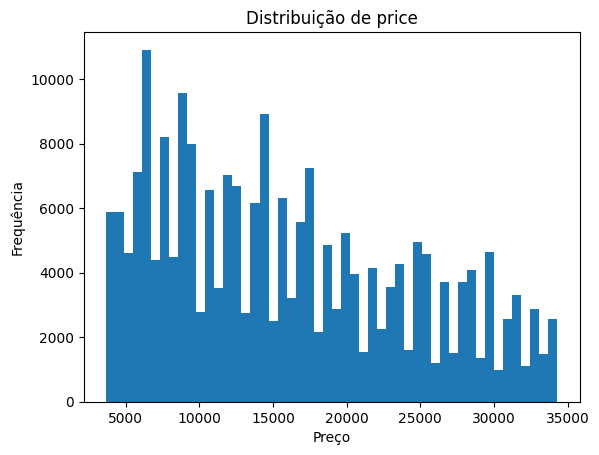

In [98]:
import matplotlib.pyplot as plt

bins, counts = df_pre_treino.select("price").rdd \
    .map(lambda x: x[0]) \
    .histogram(50)

plt.figure()
plt.bar(bins[:-1], counts, width=(bins[1]-bins[0]))
plt.title("Distribuição de price")
plt.xlabel("Preço")
plt.ylabel("Frequência")
plt.show()

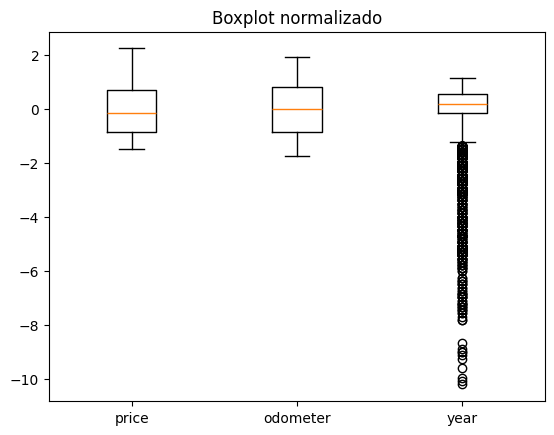

In [109]:


data_norm = []

for c in cols:
    sample = df_pre_treino.select(c) \
        .dropna() \
        .sample(False, 0.05) \
        .rdd.map(lambda x: x[0]) \
        .collect()

    sample = np.array(sample)
    sample = (sample - sample.mean()) / sample.std()

    data_norm.append(sample)

plt.figure()
plt.boxplot(data_norm)
plt.xticks(range(1, len(cols)+1), cols)
plt.title("Boxplot")
plt.show()

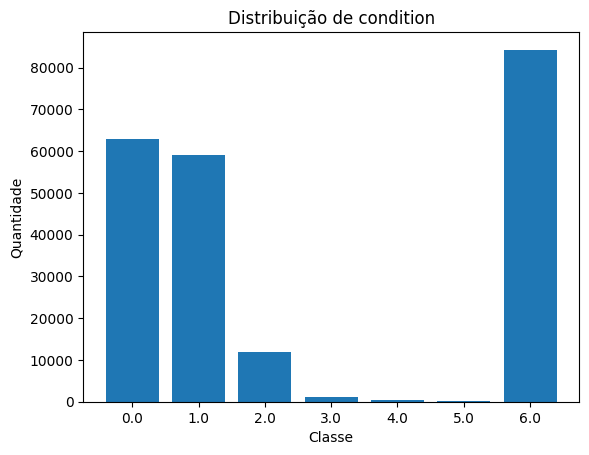

In [99]:
data = df_pre_treino.groupBy("condition_index") \
    .count() \
    .orderBy("condition_index") \
    .collect()

x = [str(row["condition_index"]) for row in data]
y = [row["count"] for row in data]

plt.figure()
plt.bar(x, y)
plt.title("Distribuição de condition")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

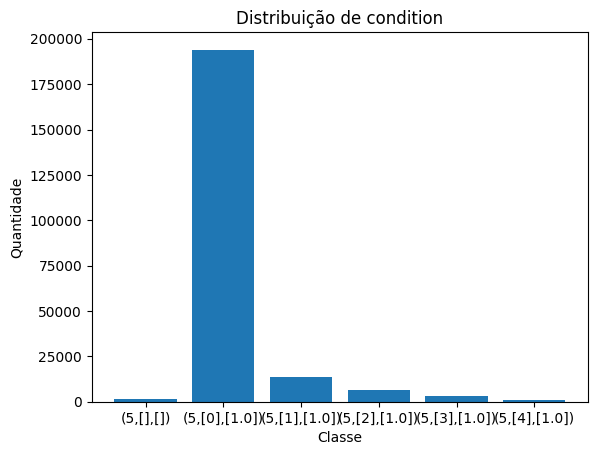

In [103]:
data = df_pre_treino.groupBy("fuel_onehot") \
    .count() \
    .orderBy("fuel_onehot") \
    .collect()

x = [str(row["fuel_onehot"]) for row in data]
y = [row["count"] for row in data]

plt.figure()
plt.bar(x, y)
plt.title("Distribuição de condition")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

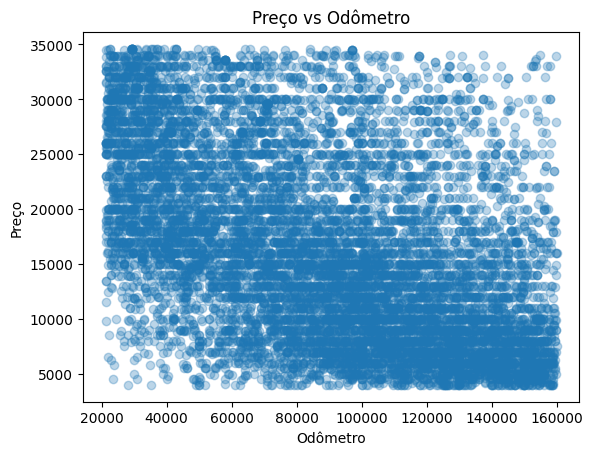

In [101]:
sample = df_pre_treino.select("price", "odometer") \
    .dropna() \
    .sample(False, 0.05) \
    .collect()

x = [row["odometer"] for row in sample]
y = [row["price"] for row in sample]

plt.figure()
plt.scatter(x, y, alpha=0.3)
plt.title("Preço vs Odômetro")
plt.xlabel("Odômetro")
plt.ylabel("Preço")
plt.show()

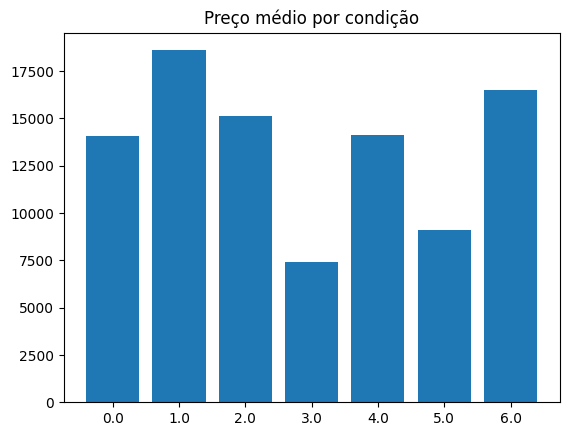

In [110]:
data = df_pre_treino.groupBy("condition_index") \
    .agg({"price": "avg"}) \
    .orderBy("condition_index") \
    .collect()

x = [str(row["condition_index"]) for row in data]
y = [row["avg(price)"] for row in data]

plt.bar(x, y)
plt.title("Preço médio por condição")
plt.show()